## Analysis of Life expectancy Dataset

The goal for this project is to establish and write out analysis and questions that satisfies the objective. This is established with data exploration, data cleansing, splitting, training and testing the dataset. Doing a parameter analsyis to recognise to witness which model gives out the best performance and more.

### Import the Life Expectancy table file

The file is named Life Expectancy Data.csv Utilise the read_csv code from the pandas method

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OrdinalEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [85]:

df = pd.read_csv('Life Expectancy Data.csv') #imports dataset
df.head() #displays the dataset for the first 5 rows

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


### Clean and explore the dataset

So the next step is to clean the dataset by detecting if there are any missing or null values and count the total missing values. If there are missing or null values then remove the rows.

In [52]:
pd.isnull(df).sum().sum() # sees the number of missing values  

2563

In [53]:
#counts the number of missing values in each column
drop = df.isnull().sum()
print(drop)

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


In [86]:
#dropping = df.dropna(axis = 'rows')
#removes all null values in the dataset
df.dropna(inplace = True)


In [55]:
#checks missing values after missing values removed
drop = df.isnull().sum()
print(drop)

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64


In [56]:
df.info() #gets further details about the dataframe

<class 'pandas.core.frame.DataFrame'>
Index: 1649 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1649 non-null   object 
 1   Year                             1649 non-null   int64  
 2   Status                           1649 non-null   object 
 3   Life expectancy                  1649 non-null   float64
 4   Adult Mortality                  1649 non-null   float64
 5   infant deaths                    1649 non-null   int64  
 6   Alcohol                          1649 non-null   float64
 7   percentage expenditure           1649 non-null   float64
 8   Hepatitis B                      1649 non-null   float64
 9   Measles                          1649 non-null   int64  
 10   BMI                             1649 non-null   float64
 11  under-five deaths                1649 non-null   int64  
 12  Polio                    

In [57]:
df.describe() #checks the important stats for each numerical columns

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000,1.649000e+03,1649.000000,1649.000000,1649.000000,1649.000000
mean,2007.840509,69.302304,168.215282,32.553062,4.533196,698.973558,79.217708,2224.494239,38.128623,44.220133,83.564585,5.955925,84.155246,1.983869,5566.031887,1.465363e+07,4.850637,4.907762,0.631551,12.119891
std,4.087711,8.796834,125.310417,120.847190,4.029189,1759.229336,25.604664,10085.802019,19.754249,162.897999,22.450557,2.299385,21.579193,6.032360,11475.900117,7.046039e+07,4.599228,4.653757,0.183089,2.795388
min,2000.000000,44.000000,1.000000,0.000000,0.010000,0.000000,2.000000,0.000000,2.000000,0.000000,3.000000,0.740000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,4.200000
25%,2005.000000,64.400000,77.000000,1.000000,0.810000,37.438577,74.000000,0.000000,19.500000,1.000000,81.000000,4.410000,82.000000,0.100000,462.149650,1.918970e+05,1.600000,1.700000,0.509000,10.300000
50%,2008.000000,71.700000,148.000000,3.000000,3.790000,145.102253,89.000000,15.000000,43.700000,4.000000,93.000000,5.840000,92.000000,0.100000,1592.572182,1.419631e+06,3.000000,3.200000,0.673000,12.300000
75%,2011.000000,75.000000,227.000000,22.000000,7.340000,509.389994,96.000000,373.000000,55.800000,29.000000,97.000000,7.470000,97.000000,0.700000,4718.512910,7.658972e+06,7.100000,7.100000,0.751000,14.000000
max,2015.000000,89.000000,723.000000,1600.000000,17.870000,18961.348600,99.000000,131441.000000,77.100000,2100.000000,99.000000,14.390000,99.000000,50.600000,119172.741800,1.293859e+09,27.200000,28.200000,0.936000,20.700000


### Comment

One of the first step was to remove any missing or null values from the dataset which is part of cleaning the data which helps improves the quality of the information and removing any sort of potential errors.

### Converting values and correlation

Variable identification - If there are any categorical values converting into numerical values using the ordencoder function and proceed to find the correlation between different values in relation to Life expectancy 

In [87]:
ord_encoder = OrdinalEncoder()
df["Country"] = ord_encoder.fit_transform(df[['Country']]) #converts categorical vals to numerical
df["Status"] = ord_encoder.fit_transform(df[['Status']]) #convert categorical value to numerical

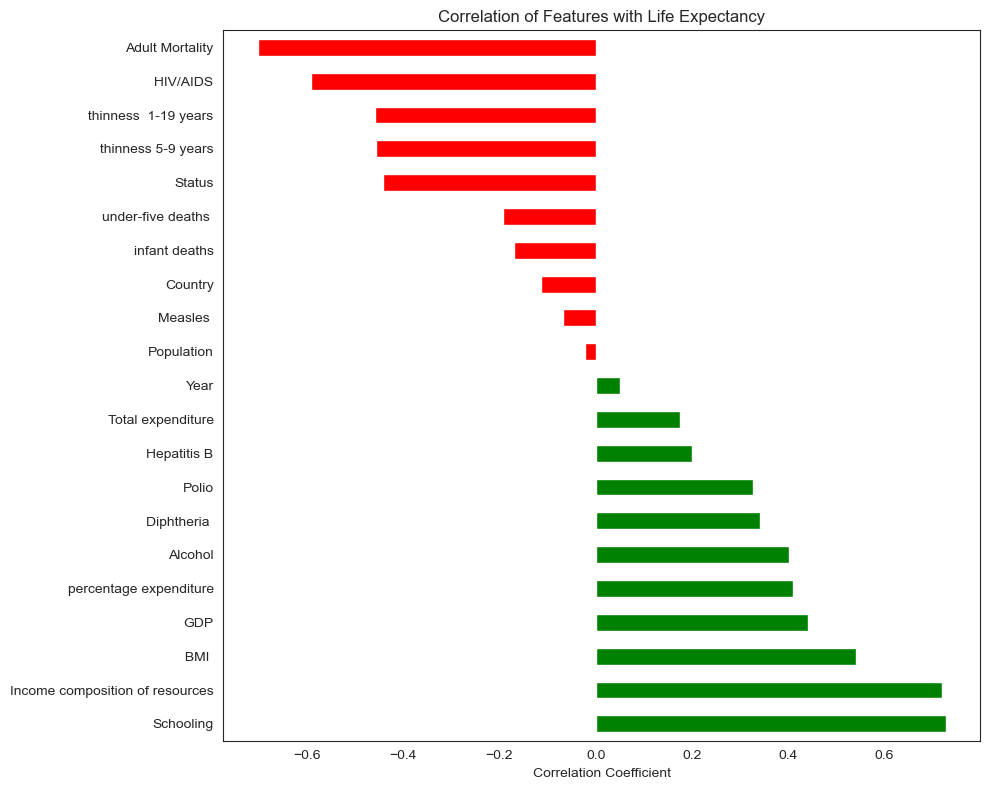

In [88]:
#Correlation heatmap showing the relationship between all numerical features and Life expectancy
correlation = df.corr()['Life expectancy '].drop('Life expectancy ').sort_values(ascending=False)
plt.figure(figsize=(10, 8))
correlation.plot(kind='barh', color=correlation.apply(lambda x: 'green' if x > 0 else 'red'))
plt.title('Correlation of Features with Life Expectancy')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

### Comment

The correlation bar chart shows the strength and direction of each feature's relationship with Life expectancy. Features like Schooling and Income composition of resources have the strongest positive correlations, while Adult Mortality and HIV/AIDS have strong negative correlations. This helps in feature selection for the predictive model. Status and GDP show moderate correlations at around 0.44 and -0.44 respectively.

### Bivariate Data Exploration

Bivarate analysis is a simple quanitative analysis which analysis two variables. In this case a scatter plot will be utilised for further evaluation.



In [64]:
sns.regplot(data = df, x = 'Alcohol', y = 'Life expectancy ') #displays  a scatterplot with alcohol and Lif eexpectancy 

<Axes: xlabel='Alcohol', ylabel='Life expectancy '>

### Comment

The scatter plot shows a relationship between Alcohol and Life expectancy has positive correlation. The graph seems unreasonable as usually as the alcohol consumption increases for indivduals the life expectancy decreases bit in this it is getting alcohol consumption of each country and not just each individual.

In [65]:
sns.regplot(data = df, x = 'GDP', y = 'Life expectancy ') #shows a scatter plot for GDP and Life expectancy

<Axes: xlabel='GDP', ylabel='Life expectancy '>

### Comment

The bivariate scatterplot shows a relation between GDP and Life expectancy. So as the GDP increases, Life expectancy increases. It is somewhat a weak positive correlation and a lot of the values are clustered up into gdp between 0 and 20000.

### Univariate analysis with data exploration

Using a hisograph is a great way to visualise the data for numerical values. In the case of univariate anylsis, there is one variable that is being analysed. Creating a histogram establishes both scenarios in data exploration and univariate analysis.

In [66]:
#Displays a histogram  for life expectancy and the count
sns.set_style('darkgrid')
sns.histplot(x = 'Life expectancy ', data = df )


<Axes: xlabel='GDP', ylabel='Life expectancy '>

### Comment

The histogram is a univariate analysis which shows the life expectancy from different countries and count of it. The data may seem unusual as it gets the life expectancy of each country between the year 2000 to 2015 but it is not displayed because the graph is specefically just for frequency of the life expectancy.



### Bivarate Histogram

In [67]:
#diplays a histogram  but in a form of a heatmap
sns.set_style('white')
sns.histplot(x = 'Life expectancy ', y = 'GDP', data = df, cbar = True) 

<Axes: xlabel='GDP', ylabel='Life expectancy '>

### Comment

This bivarate graph also can be considered as a heatmap which establishes a trend in relation to GDP and Life Expectancy.
Countries that tend to have a low GDP have a lower life expectancy as countries may be less developed so less access to medicines, health insurance and proper care.

### Utilising K-Mean Clusters

Define the number of clusters in the splitted data. The recommended number is 2 clusters so the k and k-mean = 2. Furthermore, choose K random points(recommended amount is 2). Checking the centroids and the chosen points and showing the assigned points and clustered points using the graph

In [89]:
#Transforming the dataset with a scaler for K-Means clustering
scaler = StandardScaler()
df[['Alcohol_tra', 'Life expectancy_tra ']] = scaler.fit_transform(df[['Alcohol', 'Life expectancy ']])

In [90]:
#establishing optimal numbers of clusters in the data

def optimise_k_means(data, max_k):
    means_check = []
    inertias_check = []
    
    for i in range(1, max_k):
        kmeans = KMeans(n_clusters = i, n_init = 10)
        kmeans.fit(data)
        
        means_check.append(i)
        inertias_check.append(kmeans.inertia_)
    
    #establishing the plot after the loop completes
    fig = plt.subplots(figsize =(12,7))
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.plot(means_check, inertias_check, 'o-')
    plt.grid(True)
    plt.show()

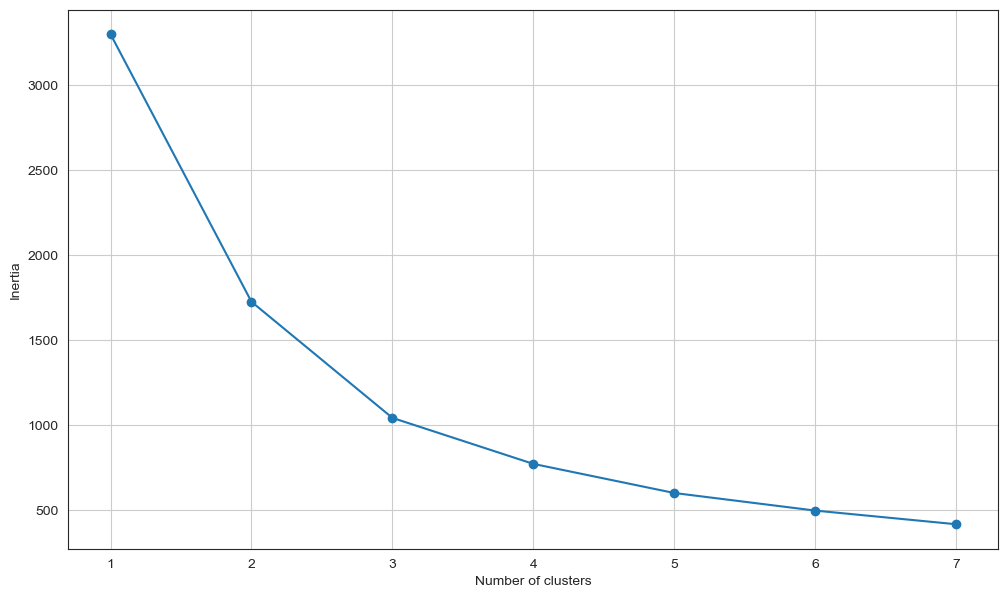

In [91]:
#showing the elbow plot with more k values for better analysis
optimise_k_means(df[['Alcohol_tra','Life expectancy_tra ']], 8)

### Comment
The elbow plot shows that the first cluster has a high level of inertia which is just above 3000 so the sum of the squared distance within the given points and also the cluster center is quite high. Once it hits 2 clusters, the value drops significantly with a value of inertia being between 1500 and 2000 and further decrease of inertia as the K-Mean value goes up. So as the clusters increase, inertia decreases. The elbow point at 2 clusters confirms that 2 is an appropriate number of clusters for this data.

In [92]:
#Setting up the K Means Cluster
kmeans = KMeans(n_clusters = 2, n_init = 10)
kmeans.fit(df[['Alcohol_tra','Life expectancy_tra ']]) #comparing with two values

KMeans(n_clusters=2, n_init=10)

In [93]:
#showing the output

df['kmeans_check2'] = kmeans.labels_ #creating a new column in DF

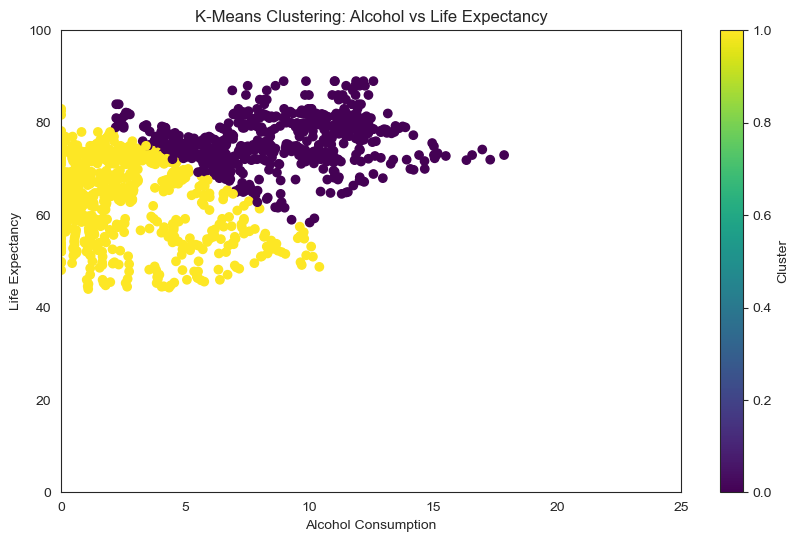

In [94]:
#plotting the scatterplot from the results with the new added column
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x = df['Alcohol'], y = df['Life expectancy '], c = df['kmeans_check2'], cmap='viridis')
plt.xlabel('Alcohol Consumption')
plt.ylabel('Life Expectancy')
plt.title('K-Means Clustering: Alcohol vs Life Expectancy')
plt.colorbar(scatter, label='Cluster')
plt.xlim(0, 25)
plt.ylim(0, 100)
plt.show()

### Comment

This shows us the density nuetron crossplot which is shown and divided with 2 clusters which shows one on the middle left of the graph and the other just  on the top but hovering towards the right. This graph helps us understand that the total cluster distance between each datapoint. K-Means was used to help break down data points into different groups usually in non overlapping subgroups

### Split the dataset

using the maching learning model, one of the most important tasks is to split the train and test model which helps with predictions and estimates the performance of the model. But first store the values you splitting in a list

In [95]:
#Storing the values in the variables of X and y
X = df[['Country', 'Status', 'Alcohol', 'GDP', 'Schooling', 'Income composition of resources', 'Adult Mortality']]
y = df['Life expectancy ']

In [96]:
#Splits the dataset into a train and test model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 142)
print("training size:", X_train.shape) #prints training size
print("testing size:", X_test.shape) #prints testting size

training size: (1319, 7)
testing size: (330, 7)


### training a linear regression model

Now the next step is to train the linear regression model which will further be used as a predictive model

In [97]:
#trains the regression model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train) #fits the trained data

LinearRegression()

# Comment

In machine learning, Data splitting is recommended as it can avoid overfitting. In this case, the data is splitting into a trainiing and testing model. This helps create a great model which are typically based on the data which indicates the creation of the model like machine learning for its accuracy.

Training a linear regression model is crucial because it is utilised for training the machine learnign algorithm and for it to recognise patterns and to further make predictions.

### Polynomial Regression with parameter analysis

Polynomial Regression is the next step to improve the linear regression model which helps capture non linear relationships within the variables which also helps to ensure that the datapoints are covered which occurs when a non-linear model is presented.

In [98]:
#First scale the data

scaler_check = StandardScaler() #storing the scaler function into a variable called scaler_check
train_X_scaler = scaler_check.fit_transform(X_train)
test_X_scaler = scaler_check.transform(X_test) #only transform test data, do not fit again

In [99]:
#transforming the data
Linear = LinearRegression() #Storing linearRegression function in the variable named Linear
poly_check = PolynomialFeatures(degree = 3)
poly_X_train = poly_check.fit_transform(train_X_scaler)
poly_X_test = poly_check.transform(test_X_scaler)
Linear.fit(poly_X_train, y_train)

LinearRegression()

### Comment

The Polynomial model that has been created is used to identify nonlinear patterns as is utilised because it can capture the complexity of the relationship unlike linear regressions. The data was transformed which makes it more suitable in the given model which can save time.

### Evaluating with Polynomial Regression

In [100]:
#Evaluating the polynomial regression model on both train and test sets
y_prediction_test = Linear.predict(poly_X_test)
y_prediction_train = Linear.predict(poly_X_train)

print("--- Polynomial Regression Results ---")
print(f"Training MAE: {mean_absolute_error(y_train, y_prediction_train):.2f}")
print(f"Testing MAE:  {mean_absolute_error(y_test, y_prediction_test):.2f}")
print(f"Training R²:  {r2_score(y_train, y_prediction_train):.4f}")
print(f"Testing R²:   {r2_score(y_test, y_prediction_test):.4f}")

--- Polynomial Regression Results ---
Training MAE: 1.74
Testing MAE:  2.00
Training R²:  0.9239
Testing R²:   0.8841


### Comment

The polynomial regression model (degree 3) shows close training and testing MAE values, indicating the model is not significantly overfitting. The R² values for both sets are also reported to compare against the linear regression. The polynomial regression improves upon the linear regression by capturing non-linear relationships, resulting in lower MAE and higher R².

### Describing the  model

Evaluating the performance of the given model with the use of metrics such as MSE, MAE, and r2. This is coming from the original trained model and displaying the predicted and real values

In [101]:
#Evaluating the linear regression model
prediction = reg_model.predict(X_test)

print("--- Linear Regression Results ---")
print(f"MSE:  {mean_squared_error(y_test, prediction):.2f}")
print(f"R²:   {r2_score(y_test, prediction):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, prediction):.2f}")

--- Linear Regression Results ---
MSE:  18.09
R²:   0.7457
MAE:  2.94


In [102]:
#Visual comparison of real vs predicted values
results_df = pd.DataFrame(data={"Real Values": y_test, "Predicted Values": prediction})
results_df.head(10) #display first 10 rows for clarity

,Real Values,Predicted Values
2032,67.3,66.780607
1875,73.0,65.564963
1820,67.0,65.150278
18,77.2,75.687077
2440,79.1,77.734864
261,69.5,69.460200
1571,57.6,59.905340
1022,57.9,67.247485
793,74.6,72.004485
2126,73.1,73.133785


### Comment

The linear regression model was evaluated using MSE, R², and MAE. The R² value of approximately 0.75 means the model explains about 75% of the variance in life expectancy using the selected features. MAE shows the average prediction error in years. Comparing against the polynomial regression results above shows how adding non-linear feature interactions improves prediction accuracy.

### Conclusion

In conclusion, the Life Expectancy dataset was cleaned by removing null values, categorical variables were encoded, and the data was explored through univariate and bivariate analysis. A correlation analysis identified that Schooling, Income composition of resources, and Adult Mortality have the strongest relationships with life expectancy. K-Means clustering revealed natural groupings in the Alcohol vs Life Expectancy data. Two predictive models were built and compared: linear regression (R² ≈ 0.75) and polynomial regression (degree 3), which improved prediction accuracy by capturing non-linear patterns. The polynomial model demonstrated better performance with lower MAE and higher R² while maintaining a balance between training and testing results, indicating no significant overfitting.